#  **Семинар №6. Компьютерное зрение. Свёрточные нейронные сети.**


In [ ]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
from torch.optim import Optimizer
from torchsummary import summary

from torchvision.datasets import CIFAR10
from torchvision.transforms.v2 import Compose, PILToTensor, ToDtype, Normalize

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rc('font', size=30)
device

### **Introduction to tensor representation of images**


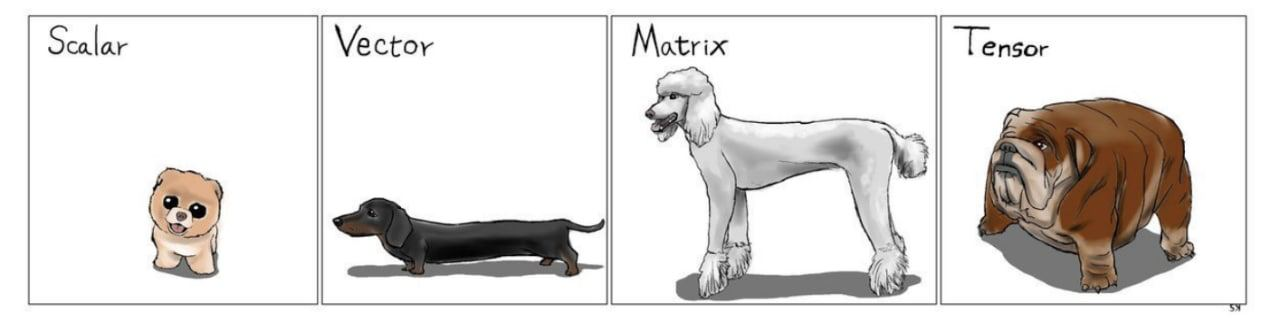

*Загрузим изображение из интернета, например, Питер Гриффина из одноименного мультсериала "Гриффины".*

In [ ]:
! wget "https://static.independent.co.uk/2021/10/29/14/newFile-8.jpg?width=1200" -O peter.jpg

In [ ]:
img = Image.open('peter.jpg')

In [ ]:
img.format

In [ ]:
img.size

In [ ]:
img.mode

In [ ]:
img

In [ ]:
img_matrix = np.array(img)

In [ ]:
img_matrix.shape

In [ ]:
img_matrix

In [ ]:
plt.figure(figsize=(20, 10))

plt.imshow(img_matrix)

plt.show()

In [ ]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matrix[:, :, i], cmap=cmap)
    plt.title(color)
    plt.show()

In [ ]:
img_matrix[:, :, 0].min(), img_matrix[:, :, 0].max()

### [**`nn.Conv2d`**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)

*Сверточные преобразования в `PyTorch` представлены модулем `nn.Conv2d` со следующими параметрами:*

- `in_channels (int)` – Количество каналов во входном изображении

- `out_channels (int`) – Количество каналов в выходном изображении

- `kernel_size (int or tuple)` – Размер ядра свертки

- `stride (int or tuple, optional)` – <страйд> (шаг ядра свертки); ***по умолчанию: 1***

- `padding (int, tuple or str, optional)` – Размер паддинга; ***по умолчанию: 0***

- `padding_mode (string, optional)` – 'zeros', 'reflect', 'replicate' or 'circular'; ***по умолчанию: 'zeros'***

- `dilation (int or tuple, optional)` – dilated convolution или <дилейшн> (расширение, шаг между элементами внутри ядра); ***по умолчанию: 1***

- `bias (bool, optional)` – добавлять ли обучаемый сдвиг; ***по умолчанию: `True`***

In [ ]:
# x -> z_1 -> z_2 -> ... -> z_n (y^hat)

# x -> z_1

# (100, 100, 3) -> (m, m, C)

# (102, 102, 3)

In [ ]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
)

In [ ]:
img_tensor = T.ToTensor()(img).unsqueeze(0)

In [ ]:
img_tensor

In [ ]:
img_tensor.shape

In [ ]:
output = conv1(img_tensor)

In [ ]:
output.shape

In [ ]:
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    padding=1
)

In [ ]:
output = conv2(img_tensor)

In [ ]:
output.shape

In [ ]:
output

In [ ]:
conv2.weight.shape

In [ ]:
conv2.bias.shape

### [**`MaxPool2d`**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html), [**`AvgPool2d`**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html)

*Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.*

Параметры:

- `kernel_size` – размер окошка

- `stride` – страйд окошка; ***по умолчанию равен kernel_size***

- `padding` – сколько нулевого паддинга добавлять по краям; ***по умолчанию: 0***

In [ ]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [ ]:
img_tensor

In [ ]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [ ]:
pooling1(img_tensor)

In [ ]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [ ]:
pooling2(img_tensor)

### [**CIFAR10 dataset**](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)

In [ ]:
from torchvision.datasets import CIFAR10
cifar = CIFAR10(root='cifar', download=True, train=True, transform=cifar_transform)
cifar_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(cifar[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(cifar_names[cifar[i][1]])

plt.show()

### **CIFAR10:**  [**normalize**](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html)

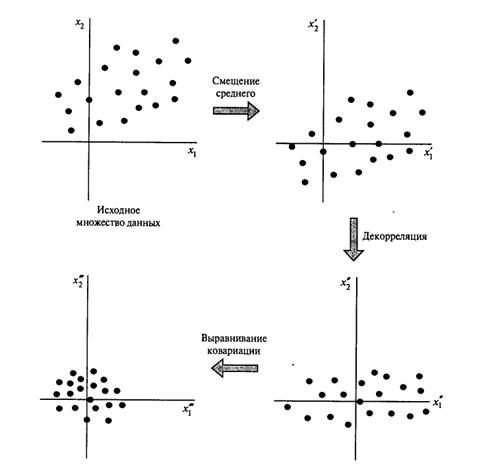

In [ ]:
from torchvision.datasets import CIFAR10

In [ ]:
dataset_cifar = CIFAR10('../datasets/cifar', train=True, transform=T.ToTensor())

In [ ]:
dataset_cifar.data.shape

In [ ]:
dataset_cifar.data

In [ ]:
dataset_cifar.data.max()

In [ ]:
means = (dataset_cifar.data / 255).mean(axis=(0, 1, 2))

means

In [ ]:
stds = (dataset_cifar.data / 255).std(axis=(0, 1, 2))

stds

In [ ]:
import torchvision.transforms as T


transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

In [ ]:
normalize = T.Normalize(mean=means, std=stds)

In [ ]:
dataset_cifar[0][0]

In [ ]:
normalized_image = normalize(dataset_cifar[0][0])

In [ ]:
normalized_image

In [ ]:
normalized_image.mean()

### **CIFAR10:** [**about data augmentation**](https://pytorch.org/vision/stable/transforms.html)
See https://arxiv.org/pdf/1911.06987v1.pdf


In [ ]:
from torchvision.transforms.v2 import RandomHorizontalFlip

cifar_transform_flip = Compose([
    RandomHorizontalFlip(1.0),
    PILToTensor(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.5, 0.5, 0.5), (0.25, 0.25, 0.25))
])

cifar_flip = CIFAR10(root='cifar', download=True, train=True, transform=cifar_transform_flip)

In [ ]:
plt.figure(figsize=(15,2))
plt.suptitle("Original")

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(cifar[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])


plt.figure(figsize=(15,2))
plt.suptitle("Flipped")

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(cifar_flip[i][0].permute(1, 2, 0) * 0.25 + 0.5)
    plt.xticks([])
    plt.yticks([])


plt.show()

### **CIFAR10 model: from simple nn to CNN**

In [ ]:
from torchvision.datasets import CIFAR10

In [ ]:
dataset_train = CIFAR10('../datasets/cifar', train=True, download=True)

In [ ]:
dataset_train.class_to_idx

In [ ]:
dataset_train[0][0]

In [ ]:
dataset_train[0][0]

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.imshow(dataset_train[0][0])
plt.show()

In [ ]:
img_matrix = np.array(dataset_train[0][0]) / 255

img_matrix.shape

In [ ]:
dataset_train = CIFAR10('../datasets/cifar', train=True, transform=T.ToTensor())

In [ ]:
dataset_train.data.shape

In [ ]:
means = (dataset_train.data / 255).mean(axis=(0, 1, 2))

means

In [ ]:
stds = (dataset_train.data / 255).std(axis=(0, 1, 2))

stds

In [ ]:
import torchvision.transforms as T


transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

In [ ]:
from torch.utils.data import DataLoader


train_dataset = CIFAR10('../datasets/cifar', train=True, transform=transforms)
valid_dataset = CIFAR10('../datasets/cifar', train=False, transform=transforms)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [ ]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        torch.save(model.state_dict(), f"checkpoints/model_{epoch}.pt")
        torch.save(optimizer.state_dict(), f"checkpoints/optimizer_{epoch}.pt")

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

In [ ]:
from torch import nn


class FirstModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # 32 x 32 x 16
            nn.ReLU(),

            nn.MaxPool2d(2),  # 16 x 16 x 16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),  # 16 x 16 x 32
            nn.ReLU(),

            nn.MaxPool2d(2),  # 8 x 8 x 32

            nn.Flatten(),

            nn.Linear(8 * 8 * 32, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
from torch.optim import Adam


model = FirstModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'First simple model')

In [ ]:
model, optimizer

In [ ]:
model = FirstModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

epoch = 7

model.load_state_dict(torch.load(f"checkpoints/model_{epoch}.pt"))
optimizer.load_state_dict(torch.load(f"checkpoints/optimizer_{epoch}.pt"))


In [ ]:
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 3, 'First simple model')

In [ ]:
class SecondModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.ReLU(),

            nn.MaxPool2d(2),  # 16 x 16 x 32

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.ReLU(),

            nn.MaxPool2d(2),  # 8 x 8 x 64

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.ReLU(),

            nn.MaxPool2d(2),  # 4 x 4 x 128

            nn.Flatten(),

            nn.Linear(4 * 4 * 128, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = SecondModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'Second simple model')

In [ ]:
class ThirdModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 16 x 16 x 32

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 8 x 8 x 64

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 4 x 4 x 128

            nn.Flatten(),

            nn.Linear(4 * 4 * 128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = ThirdModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'Third advanced model')

In [ ]:
class FourthModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 16 x 16 x 32
            nn.Dropout2d(p=0.2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 8 x 8 x 32
            nn.Dropout2d(p=0.2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 4 x 4 x 128
            nn.Dropout2d(p=0.2),

            nn.Flatten(),

            nn.Linear(4 * 4 * 128, 512),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 20, 'Fourth super advanced model')

In [ ]:
train_transforms = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.8, 1.1)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomAdjustSharpness(sharpness_factor=2),
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

test_transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

train_dataset = CIFAR10('../datasets/cifar', train=True, transform=train_transforms)
valid_dataset = CIFAR10('../datasets/cifar', train=False, transform=test_transforms)

train_loader_augs1 = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader_augs1 = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader_augs1, valid_loader_augs1,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + custom augmentations'
)

In [ ]:
train_transforms = T.Compose(
    [
        T.RandAugment(),
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

test_transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

train_dataset = CIFAR10('../datasets/cifar', train=True, transform=train_transforms)
valid_dataset = CIFAR10('../datasets/cifar', train=False, transform=test_transforms)

train_loader_augs2 = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader_augs2 = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader_augs2, valid_loader_augs2,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + random augmentations'
)

In [ ]:
train_transforms = T.Compose(
    [
        T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

test_transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

train_dataset = CIFAR10('cifar', train=True, transform=train_transforms)
valid_dataset = CIFAR10('cifar', train=False, transform=test_transforms)

train_loader_augs3 = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader_augs3 = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader_augs3, valid_loader_augs3,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + best learned augmentations'
)

In [ ]:
# https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

In [ ]:
from torch.optim.lr_scheduler import StepLR

model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

scheduler = StepLR(optimizer, step_size=25, gamma=0.1)

fit(
    model,
    train_loader_augs1, valid_loader_augs1,
    optimizer, loss_fn, device, 40, 'Fourth super advanced model + best learned augmentations + lr schedule', scheduler
)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def predict(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()

    prediction = []

    for x, _ in tqdm(loader):
        output = model(x.to(device)).cpu()

        prediction.append(torch.argmax(output, dim=1))

    prediction = torch.cat(prediction)

    return prediction


In [ ]:
def get_labels(loader):
    labels = []

    for _, y in tqdm(loader):
        labels.append(y)

    return torch.cat(labels, dim=0)

In [ ]:
prediction = predict(model, valid_loader, device)
labels = get_labels(valid_loader)

In [ ]:
prediction

In [ ]:
labels

In [ ]:
torch.mean((prediction == labels).to(torch.float32))

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def predict_tta(model: nn.Module, loader: DataLoader, device: torch.device, iterations: int=2):
    model.eval()

    prediction = []

    for iteration in range(iterations):
        single_prediction = []

        for x, _ in tqdm(loader):
            output = model(x.to(device)).cpu()

            single_prediction.append(output)

        prediction.append(torch.vstack(single_prediction))

    prediction = torch.argmax(torch.mean(torch.stack(prediction), dim=0), dim=1)

    return prediction

In [ ]:
transforms = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.8, 1.2)),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

valid_dataset = CIFAR10('../datasets/cifar', train=False, transform=transforms)

valid_loader_augs_tta = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
prediction_tta = predict_tta(model, valid_loader_augs_tta, device, iterations=20)

In [ ]:
torch.mean((prediction_tta == labels).to(torch.float32))

### *See* [***MNIST***](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html): *convolutional nn*

In [ ]:
from torchvision.datasets import MNIST

In [ ]:
mnist_train = MNIST(
    "../datasets/mnist",
    train=True,
   download=True
)

In [ ]:
mnist_train

In [ ]:
mnist_train.data.shape

In [ ]:
mnist_train.test_labels.shape

In [ ]:
mnist_train[0][0]

In [ ]:
# 60000 * 28 * 28

In [ ]:
# 224 * 224 * 3 * 100_000

In [ ]:
# / <- [path1, path2, ..., path_n]

# path1 -> img1 -> tensor1

In [ ]:
means = (mnist_train.data / 255).mean(axis=(0, 1, 2))

means

In [ ]:
stds = (mnist_train.data / 255).std(axis=(0, 1, 2))

stds

In [ ]:
import torchvision.transforms as T


transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=means, std=stds)
    ]
)

In [ ]:
mnist_train = MNIST(
    "../datasets/mnist",
    train=True,
    download=True,
    transform=transforms
)

In [ ]:
mnist_valid = MNIST(
    "../datasets/mnist",
    train=False,     #!
    download=True,
    transform=transforms
)

In [ ]:
len(mnist_train)

In [ ]:
len(mnist_valid)

In [ ]:
mnist_train[0][0]

In [ ]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
valid_loader = DataLoader(mnist_valid, batch_size=64, shuffle=False)

In [ ]:
plt.figure(figsize=(10, 10))
plt.title(f'{mnist_train[15][1]}')
plt.imshow(mnist_train[15][0][0])

plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.title(f'{mnist_train[10000][1]}')
plt.imshow(mnist_train[10000][0][0])

plt.show()

In [ ]:
def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


In [ ]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)


In [ ]:
sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [ ]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

In [ ]:
# (28, 28) -> (784)

In [ ]:
MNIST_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),  # 28 x 28 -> 24 x 24
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 24 x 24 -> 12 x 12

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5),  # 12 x 12 -> 8 x 8
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 8 x 8 -> 4 x 4

    nn.Flatten(),  # 4 x 4 x 16 -> 4 * 4 * 16
    nn.Linear(4 * 4 * 16, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(MNIST_model.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

In [ ]:
fit(MNIST_model, train_loader, valid_loader, optimizer, loss_fn, 15, 'CONV')

### *See* [***Models and pre-trained weights***](https://pytorch.org/vision/stable/models.html)

See **Ildus Sadrtdinov, https://disk.yandex.ru/i/ZcEDws6FTNrGmQ**

In [ ]:
# from https://pytorch.org/vision/stable/models.html , follow ->
from torchvision.models import alexnet
from torchvision.models import vgg11_bn
from torchvision.models import googlenet
from torchvision.models import resnet18

In [ ]:
model = alexnet()

model

In [ ]:
sum(p.numel() for p in model.classifier.parameters())

In [ ]:
model = vgg11_bn()

model

In [ ]:
sum(p.numel() for p in model.parameters())

In [ ]:
model = googlenet(init_weights=False)

model

In [ ]:
sum(p.numel() for p in model.parameters())

In [ ]:
model = resnet18()

model

In [ ]:
sum(p.numel() for p in model.parameters())

In [ ]:
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet('../datasets/pets', download=True)

In [ ]:
dataset[0]

In [ ]:
dataset[0][0]

In [ ]:
len(dataset)

In [ ]:
dataset.classes

In [ ]:
num_classes = len(dataset.classes)

num_classes

In [ ]:
transform = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

train_dataset = OxfordIIITPet('../datasets/pets', transform=transform)
valid_dataset = OxfordIIITPet('../datasets/pets', transform=transform, split='test')

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [ ]:
from torchvision.models import AlexNet_Weights, ResNet18_Weights

In [ ]:
model = alexnet()

In [ ]:
next(iter(model.parameters()))

In [ ]:
model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

model

In [ ]:
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

model

In [ ]:
sum(p.numel() for p in model.features.parameters())

In [ ]:
sum(p.numel() for p in model.classifier.parameters())

In [ ]:
device = torch.device("cuda:0")

In [ ]:
from torch.optim import Adam

loss_fn = torch.nn.CrossEntropyLoss()

model = model.to(device)

model.features.requires_grad_(False)
model.features[8].requires_grad_(True)
model.features[10].requires_grad_(True)

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 5, 'Alexnet pretrained'
)

In [ ]:
model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
model.requires_grad_(False)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

model = model.to(device)

In [ ]:
optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 5, 'Alexnet not pretrained'
)

In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model

In [ ]:
model.fc = nn.Linear(in_features=512, out_features=num_classes)

model

In [ ]:
model = model.to(device)

model.requires_grad_(False)
model.layer4.requires_grad_(True)
model.fc.requires_grad_(True)

# optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

optimizer = Adam(
    [
        {'params': model.fc.parameters(), 'lr': 1e-3},
        {'params': model.layer4.parameters(), 'lr': 1e-4}
    ]
)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 10, 'ResNet18 pretrained'
)

In [ ]:
model = resnet18()

model.fc = nn.Linear(in_features=512, out_features=num_classes)

model

In [ ]:
model = model.to(device)


optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 10, 'ResNet18 not pretrained'
)

In [ ]:
torch.save(model.state_dict(), 'resnet.pt')

In [ ]:
model = resnet18(pretrained=False)

In [ ]:
model.load_state_dict(torch.load('resnet.pt'))

In [ ]:
torch.save(
    {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    },
    'checkpoint.pt'
)

### *Additionals:* [***skip connection***](https://engineering.purdue.edu/DeepLearn/pdf-kak/SkipConsAndBN.pdf), [***PyTorch ignite and utilities***](https://pytorch-ignite.ai/)

[**skip connection:**](https://arxiv.org/pdf/1512.03385.pdf)  https://habr.com/ru/articles/688350/

https://www.kaggle.com/code/krishanudb/tutorial-on-convolutional-nets-in-pytorch

See **Ildus Sadrtdinov, ResNet https://disk.yandex.ru/i/ZcEDws6FTNrGmQ**

---


See [**getting-started**](https://pytorch-ignite.ai/tutorials/beginner/01-getting-started)

See [*engine:*](https://pytorch.org/ignite/engine.html) [*trainer*](https://pytorch.org/ignite/generated/ignite.engine.create_supervised_trainer.html) and [*evaluators*](https://pytorch.org/ignite/generated/ignite.engine.create_supervised_evaluator.html), [*ignite.metrics (loss)*](https://pytorch.org/ignite/metrics.html), [*Events*](https://pytorch.org/ignite/generated/ignite.engine.events.Events.html)

See [*handlers*](https://pytorch.org/ignite/handlers.html): lr scheduler

See [*adding checkpoints*](https://pytorch.org/ignite/generated/ignite.handlers.checkpoint.ModelCheckpoint.html#modelcheckpoint)

See [*pretty loggers*](https://pytorch-ignite.ai/how-to-guides/10-loggers)

___

See also https://github.com/Lightning-AI/pytorch-lightning

### *Additionals:* [***CV overview: more machine learning tasks***](https://docs.yandex.ru/docs/view?url=ya-disk-public%3A%2F%2F6LrFjF%2ByPi4f%2BR%2FzvIx%2Bc0QJPc11jAo8hdzAZz%2FYmUB3KpIW4kdP2Q37IjD0LU1Gq%2FJ6bpmRyOJonT3VoXnDag%3D%3D%3A%2FLection%207.%20CV%20overview.pdf&name=Lection%207.%20CV%20overview.pdf&nosw=1)

#### [**Semantic segmentation**](https://en.wikipedia.org/wiki/Image_segmentation)
See https://habr.com/ru/articles/740824/

See https://www.kaggle.com/code/akshitsharma1/unet-architecture-explained-in-one-shot-tutorial

In [ ]:
import torch
import matplotlib.pyplot as plt

In [ ]:
import torchvision.transforms.v2 as T
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet('../datasets/pets', target_types='segmentation', download=True)

In [ ]:
dataset[0]

In [ ]:
dataset[0][0]

In [ ]:
plt.imshow(dataset[0][1])

In [ ]:
import numpy as np

np.unique(np.array(dataset[0][1]))

In [ ]:
dataset[100][0]

In [ ]:
plt.imshow(dataset[100][1])

In [ ]:
(3, n, n) -> (C, n, n)


In [ ]:
transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.ToTensor(),
    ]
)

target_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.PILToTensor(),
        T.Lambda(lambda x: (x - 1).long())
    ]
)

train_dataset = OxfordIIITPet('../datasets/pets', transform=transform, target_transform=target_transform, target_types='segmentation')
valid_dataset = OxfordIIITPet('../datasets/pets', transform=transform, split='test', target_transform=target_transform, target_types='segmentation')

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, num_workers=8)

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(data_loader):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        _, y_pred = output.max(dim=1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y == y_pred).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), correct / total


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(data_loader):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        _, y_pred = output.max(dim=1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y == y_pred).sum().item()

    return total_loss / len(data_loader), correct / total


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [ ]:
import numpy as np
from PIL import Image


@torch.inference_mode()
def visualize(model, batch, device):
    model.eval()

    xs, ys = batch

    to_pil = T.ToPILImage()

    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = model(x.unsqueeze(0).to(device)).cpu().squeeze(0).max(dim=0)[1]

        fig, ax = plt.subplots(1, 3, figsize=(24, 8), facecolor='white')

        ax[0].imshow(to_pil(x))
        ax[1].imshow(to_pil(y.to(torch.uint8)))
        ax[2].imshow(to_pil(prediction.to(torch.uint8)))

        ax[0].axis('off')
        ax[1].axis('off')
        ax[2].axis('off')

        ax[0].set_title('Original image')
        ax[1].set_title('Segmentation mask')
        ax[2].set_title('Prediction')

        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= 9:
            break

In [ ]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    valid_iterator = iter(valid_loader)

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        visualize(model, next(valid_iterator), device)

Unet paper https://arxiv.org/abs/1505.04597

In [ ]:
def conv_plus_conv(in_channels: int, out_channels: int):
    """
    Makes UNet block
    :param in_channels: input channels
    :param out_channels: output channels
    :return: UNet block
    """
    return nn.Sequential(
        nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.BatchNorm2d(num_features=out_channels),
        nn.LeakyReLU(0.2),
        nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.BatchNorm2d(num_features=out_channels),
        nn.LeakyReLU(0.2),
    )


class UNET(nn.Module):
    def __init__(self):
        super().__init__()

        base_channels = 32

        self.down1 = conv_plus_conv(3, base_channels)
        self.down2 = conv_plus_conv(base_channels, base_channels * 2)
        self.down3 = conv_plus_conv(base_channels * 2, base_channels * 4)
        self.down4 = conv_plus_conv(base_channels * 4, base_channels * 8)
        self.down5 = conv_plus_conv(base_channels * 8, base_channels * 16)

        self.up1 = conv_plus_conv(base_channels * 2, base_channels)
        self.up2 = conv_plus_conv(base_channels * 4, base_channels)
        self.up3 = conv_plus_conv(base_channels * 8, base_channels * 2)
        self.up4 = conv_plus_conv(base_channels * 16, base_channels * 4)
        self.up5 = conv_plus_conv(base_channels * 32, base_channels * 8)

        self.bottleneck = conv_plus_conv(base_channels * 16, base_channels * 16)

        self.out = nn.Conv2d(in_channels=base_channels, out_channels=3, kernel_size=1)

        self.downsample = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # x.shape = (N, N, 3)

        residual1 = self.down1(x)  # x.shape: (N, N, 3) -> (N, N, base_channels)
        x = self.downsample(residual1)  # x.shape: (N, N, base_channels) -> (N // 2, N // 2, base_channels)

        residual2 = self.down2(x)  # x.shape: (N // 2, N // 2, base_channels) -> (N // 2, N // 2, base_channels * 2)
        x = self.downsample(residual2)  # x.shape: (N // 2, N // 2, base_channels * 2) -> (N // 4, N // 4, base_channels * 2)

        residual3 = self.down3(x)
        x = self.downsample(residual3)

        residual4 = self.down4(x)
        x = self.downsample(residual4)

        residual5 = self.down5(x)
        x = self.downsample(residual5)

        # LATENT SPACE DIMENSION DIM = N // 32
        # SOME MANIPULATION MAYBE
        x = self.bottleneck(x)  # x.shape: (N // 32, N // 32, base_channels * 16) -> (N // 32, N // 32, base_channels * 16)
        # SOME MANIPULATION MAYBE
        # LATENT SPACE DIMENSION DIM = N // 32

        x = nn.functional.interpolate(x, scale_factor=2)  # x.shape: (N // 32, N // 32, base_channels * 16) -> (N // 16, N // 16, base_channels * 16)
        x = torch.cat((x, residual5), dim=1)  # 32
        x = self.up5(x)  # 8

        x = nn.functional.interpolate(x, scale_factor=2)  # 8
        x = torch.cat((x, residual4), dim=1)  # 16
        x = self.up4(x)  # 4

        x = nn.functional.interpolate(x, scale_factor=2)
        x = torch.cat((x, residual3), dim=1)
        x = self.up3(x)

        x = nn.functional.interpolate(x, scale_factor=2)  # x.shape: (N // 4, N // 4, base_channels * 2) -> (N // 2, N // 2, base_channels * 2)
        x = torch.cat((x, residual2), dim=1)  # x.shape: (N // 2, N // 2, base_channels * 2) -> (N // 2, N // 2, base_channels * 4)
        x = self.up2(x)  # x.shape: (N // 2, N // 2, base_channels * 4) -> (N // 2, N // 2, base_channels)

        x = nn.functional.interpolate(x, scale_factor=2)  # x.shape: (N // 2, N // 2, base_channels) -> (N, N, base_channels)
        x = torch.cat((x, residual1), dim=1)  # x.shape: (N, N, base_channels) -> (N, N, base_channels * 2)
        x = self.up1(x)  # x.shape: (N, N, base_channels * 2) -> (N, N, base_channels)

        x = self.out(x)  # x.shape: (N, N, base_channels) -> (N, N, classes)

        return x

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

loss_fn = nn.CrossEntropyLoss()

In [ ]:
from torch.optim import Adam


model = UNET().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 15, 'UNET segmentation')

In [ ]:
visualize(model, next(iter(train_loader)), device)

#### [**Object detection**](https://en.wikipedia.org/wiki/Object_detection)

See ***SotA*** https://docs.ultralytics.com/ru/models/yolov9/

See ***SotA*** https://openai.com/research/clip
(https://github.com/openai/CLIP)


See also [***Roboflow***](https://roboflow.com/): *a popular image markup* *platform* https://blog.roboflow.com/data-augmentation/


In [ ]:
from torchvision.datasets import VOCDetection

dataset = VOCDetection('../datasets/voc', download=True)

In [ ]:
len(dataset)

In [ ]:
dataset[0]

In [ ]:
dataset[0][0]

In [ ]:
target_names = []

for obj in dataset:
    target_names.extend([x['name'] for x in obj[1]['annotation']['object']])

target_names = list(set(target_names))

In [ ]:
target_names

In [ ]:
target2idx = {name: i for i, name in enumerate(target_names)}
idx2target = {i: name for i, name in enumerate(target_names)}

target2idx, idx2target

In [ ]:
def target_transform(voc_target):
    target = {}

    target['boxes'] = torch.tensor(
        [
            [
                float(x['bndbox']['xmin']),
                float(x['bndbox']['ymin']),
                float(x['bndbox']['xmax']),
                float(x['bndbox']['ymax'])
            ] for x in voc_target['annotation']['object']
        ],
        dtype=torch.float32
    )
    target['labels'] = torch.tensor([target2idx[x['name']] for x in voc_target['annotation']['object']], dtype=torch.int64)

    return target

In [ ]:
target_transform(dataset[0][1])

In [ ]:
from torchvision.utils import draw_bounding_boxes


def show(imgs):
    to_pil = T.ToPILImage()

    if not isinstance(imgs, list):
        imgs = [imgs]

    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(16, 8))

    for i, img in enumerate(imgs):
        img = img.detach()
        img = to_pil(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

def draw_boxes_single_image(image, boxes, labels):
    colors = ["red" for _ in boxes]

    show(draw_bounding_boxes(image, boxes, labels, colors=colors, width=5))

In [ ]:
draw_boxes_single_image(
    T.PILToTensor()(dataset[0][0]),
    target_transform(dataset[0][1])['boxes'],
    [idx2target[label.item()] for label in target_transform(dataset[0][1])['labels']]
)

In [ ]:
for i in range(1, 10):
    draw_boxes_single_image(
        T.PILToTensor()(dataset[i][0]),
        target_transform(dataset[i][1])['boxes'],
        [idx2target[label.item()] for label in target_transform(dataset[i][1])['labels']]
    )

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = VOCDetection(
    '../datasets/voc',
    image_set='train',
    transform=T.ToTensor(),
    target_transform=target_transform
)

valid_dataset = VOCDetection(
    '../datasets/voc',
    image_set='val',
    transform=T.ToTensor(),
    target_transform=target_transform
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=8, pin_memory=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=8, pin_memory=True, collate_fn=collate_fn)

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


def get_detection_model():
    model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1)

    model.requires_grad_(False)

    model.roi_heads.box_predictor = FastRCNNPredictor(1024, len(target_names))

    return model

In [ ]:
model = get_detection_model()

In [ ]:
model

In [ ]:
from torchvision.ops import batched_nms


def intersection_over_union(dt_bbox, gt_bbox):
    int_x0 = max(dt_bbox[0], gt_bbox[0])
    int_y0 = max(dt_bbox[1], gt_bbox[1])

    int_x1 = min(dt_bbox[2], gt_bbox[2])
    int_y1 = min(dt_bbox[3], gt_bbox[3])

    intersection = max(int_x1 - int_x0, 0) * max(int_y1 - int_y0, 0)
    dt_area = (dt_bbox[2] - dt_bbox[0]) * (dt_bbox[3] - dt_bbox[1])
    gt_area = (gt_bbox[2] - gt_bbox[0]) * (gt_bbox[3] - gt_bbox[1])

    return intersection / (dt_area + gt_area - intersection)


def apply_nms(orig_prediction, iou_thresh=0.3):

    keep = batched_nms(orig_prediction['boxes'], orig_prediction['scores'], orig_prediction['labels'], iou_thresh)

    final_prediction = orig_prediction

    final_prediction['boxes'] = final_prediction['boxes'][keep]
    final_prediction['scores'] = final_prediction['scores'][keep]
    final_prediction['labels'] = final_prediction['labels'][keep]

    return final_prediction


@torch.inference_mode()
def visualize(model, batch, device):
    model.eval()

    to_pil = T.ToPILImage()
    to_tensor = T.PILToTensor()

    xs, ys = batch

    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = {k: v.to(device) for k, v in model([x.to(device)])[0].items()}

        prediction = apply_nms(prediction)

        x = to_tensor(to_pil(x.cpu()))

        true_boxes = draw_bounding_boxes(x, boxes=y['boxes'], labels=[idx2target[label.item()] for label in y['labels']], width=5, colors='red')
        predicted_boxes = draw_bounding_boxes(x, boxes=prediction['boxes'], labels=[idx2target[label.item()] for label in prediction['labels']], width=5, colors='red')

        fig, ax = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

        ax[0].imshow(to_pil(true_boxes))
        ax[1].imshow(to_pil(predicted_boxes))

        ax[0].axis('off')
        ax[1].axis('off')

        ax[0].set_title('Target boxes')
        ax[1].set_title('Predicted boxes')

        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= 9:
            break

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, device: torch.device):
    model.train()

    for x, y in tqdm(data_loader):
        x = list(_.to(device).float() for _ in x)
        y = [{k: v.to(device) for k, v in t.items()} for t in y]

        optimizer.zero_grad()

        output = model(x, y)

        loss_sum = sum(loss for loss in output.values())

        loss_sum.backward()

        optimizer.step()

In [ ]:
! pip install torchmetrics

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchmetrics.detection.mean_ap import MeanAveragePrecision


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, device: torch.device):
    model.eval()

    metric = MeanAveragePrecision()

    for x, y in tqdm(data_loader):
        x = list(_.to(device).float() for _ in x)

        output = model(x)

        output = [{k: v.cpu() for k, v in t.items()} for t in output]

        metric.update(output, y)

    return metric.compute()['map']


In [ ]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, device, num_epochs, title):

    train_iterator = iter(train_loader)
    valid_iterator = iter(valid_loader)

    for epoch in range(num_epochs):
        train(model, train_loader, optimizer, device)

        clear_output()

        visualize(model, next(train_iterator), device)
        visualize(model, next(valid_iterator), device)

In [ ]:
model = get_detection_model().to(device)

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

In [ ]:
fit(model, train_loader, valid_loader, optimizer, device, 5, 'Faster R-CNN finetune')

In [ ]:
visualize(model, next(iter(train_loader)), device)

In [ ]:
train_map = evaluate(model, train_loader, device)
valid_map = evaluate(model, valid_loader, device)

print(f'Train mAP {train_map:.5f} Valid mAP {valid_map:.5f}')

In [ ]:
! pip install torchmetrics[detection]